<a href="https://colab.research.google.com/github/Minakshi654/DocSense--CNN-based-Document-Classifier/blob/main/LTSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("GPU available:", torch.cuda.is_available())

GPU available: True


In [7]:
import pandas as pd

# Classic, reliable retail sales dataset (Australian wine sales - commonly used for time series teaching)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head(10))

(36, 2)
  Month  Sales
0  1-01  266.0
1  1-02  145.9
2  1-03  183.1
3  1-04  119.3
4  1-05  180.3
5  1-06  168.5
6  1-07  231.8
7  1-08  224.5
8  1-09  192.8
9  1-10  122.9


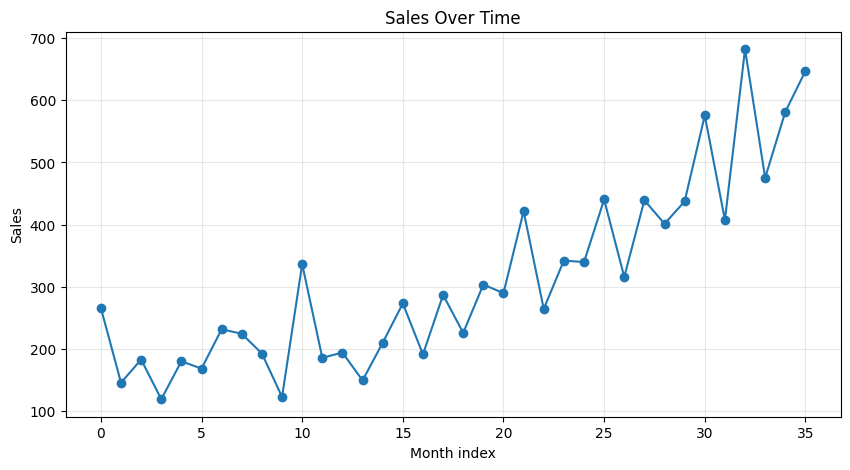

Min sales: 119.3
Max sales: 682.0
Mean sales: 312.59999999999997


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df["Sales"], marker="o")
plt.title("Sales Over Time")
plt.xlabel("Month index")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.show()

print("Min sales:", df["Sales"].min())
print("Max sales:", df["Sales"].max())
print("Mean sales:", df["Sales"].mean())

In [9]:
from sklearn.preprocessing import MinMaxScaler

sales = df["Sales"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
sales_scaled = scaler.fit_transform(sales)

print("Original first 5:", sales[:5].flatten())
print("Scaled first 5:", sales_scaled[:5].flatten())

Original first 5: [266.  145.9 183.1 119.3 180.3]
Scaled first 5: [0.2607073  0.04727208 0.11338191 0.         0.1084059 ]


In [10]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 3
X, y = create_sequences(sales_scaled, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (33, 3, 1)
y shape: (33, 1)


In [11]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train examples:", len(X_train))
print("Test examples:", len(X_test))

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train tensor shape:", X_train.shape)

Train examples: 26
Test examples: 7
X_train tensor shape: torch.Size([26, 3, 1])


In [12]:
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(SalesLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)  # final layer: memory -> single sales prediction

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        # we only care about the LAST time step's output for prediction
        last_output = lstm_out[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SalesLSTM(input_size=1, hidden_size=32, num_layers=1).to(device)
print(model)

SalesLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [13]:
criterion = nn.MSELoss()  # Mean Squared Error - measures how far off our number predictions are
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

X_train_dev = X_train.to(device)
y_train_dev = y_train.to(device)

num_epochs = 200
losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_dev)
    loss = criterion(outputs, y_train_dev)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {loss.item():.6f}")

Epoch [20/200]  Loss: 0.029474
Epoch [40/200]  Loss: 0.021710
Epoch [60/200]  Loss: 0.016662
Epoch [80/200]  Loss: 0.014127
Epoch [100/200]  Loss: 0.013932
Epoch [120/200]  Loss: 0.013724
Epoch [140/200]  Loss: 0.013366
Epoch [160/200]  Loss: 0.012667
Epoch [180/200]  Loss: 0.012014
Epoch [200/200]  Loss: 0.011915


In [14]:
model.eval()
with torch.no_grad():
    X_test_dev = X_test.to(device)
    test_predictions = model(X_test_dev).cpu().numpy()

# Reverse the scaling to get back real sales numbers
test_predictions_real = scaler.inverse_transform(test_predictions)
y_test_real = scaler.inverse_transform(y_test.numpy())

print("Predicted vs Actual:")
for pred, actual in zip(test_predictions_real.flatten(), y_test_real.flatten()):
    print(f"Predicted: {pred:.1f}   Actual: {actual:.1f}")

Predicted vs Actual:
Predicted: 438.8   Actual: 437.4
Predicted: 443.5   Actual: 575.5
Predicted: 495.2   Actual: 407.6
Predicted: 575.0   Actual: 682.0
Predicted: 524.4   Actual: 475.3
Predicted: 658.1   Actual: 581.3
Predicted: 579.4   Actual: 646.9


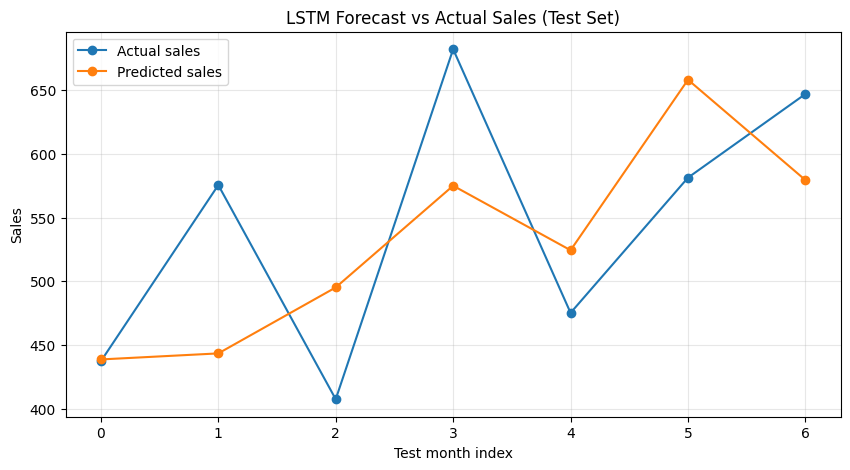

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test_real)), y_test_real, marker="o", label="Actual sales")
plt.plot(range(len(test_predictions_real)), test_predictions_real, marker="o", label="Predicted sales")
plt.title("LSTM Forecast vs Actual Sales (Test Set)")
plt.xlabel("Test month index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test_real, test_predictions_real)
mape = mean_absolute_percentage_error(y_test_real, test_predictions_real)

print(f"Mean Absolute Error: {mae:.2f} units")
print(f"Mean Absolute Percentage Error: {mape*100:.2f}%")

Mean Absolute Error: 74.49 units
Mean Absolute Percentage Error: 13.49%


In [17]:
# Naive baseline: "predict next month = same as this month" (no model needed)
naive_predictions = y_test_real[:-1]  # shift by one
naive_actual = y_test_real[1:]

naive_mae = mean_absolute_error(naive_actual, naive_predictions)
naive_mape = mean_absolute_percentage_error(naive_actual, naive_predictions)

print(f"Naive baseline MAE: {naive_mae:.2f} units")
print(f"Naive baseline MAPE: {naive_mape*100:.2f}%")
print(f"\nOur LSTM MAE: {mae:.2f} units")
print(f"Our LSTM MAPE: {mape*100:.2f}%")

Naive baseline MAE: 159.78 units
Naive baseline MAPE: 29.55%

Our LSTM MAE: 74.49 units
Our LSTM MAPE: 13.49%


In [18]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 3 years of daily data
days = 365 * 3
date_range = pd.date_range(start="2023-01-01", periods=days, freq="D")

# Base trend: slow steady growth over time
trend = np.linspace(1000, 1400, days)

# Seasonality: summer spike (beverages sell more in heat), using a yearly sine wave
day_of_year = date_range.dayofyear
seasonality = 300 * np.sin(2 * np.pi * (day_of_year - 80) / 365)  # peak around June/July

# Weekly pattern: higher sales on weekends
weekday = date_range.dayofweek
weekly_pattern = np.where(weekday >= 5, 150, 0)  # Sat/Sun boost

# Random noise (real-world unpredictability)
noise = np.random.normal(0, 60, days)

sales = trend + seasonality + weekly_pattern + noise
sales = np.clip(sales, 200, None)  # sales can't go negative

coke_df = pd.DataFrame({"date": date_range, "sales": sales})
print(coke_df.shape)
print(coke_df.head())

(1095, 2)
        date       sales
0 2023-01-01  886.448347
1 2023-01-02  699.839636
2 2023-01-03  748.573397
3 2023-01-04  802.756702
4 2023-01-05  699.074385


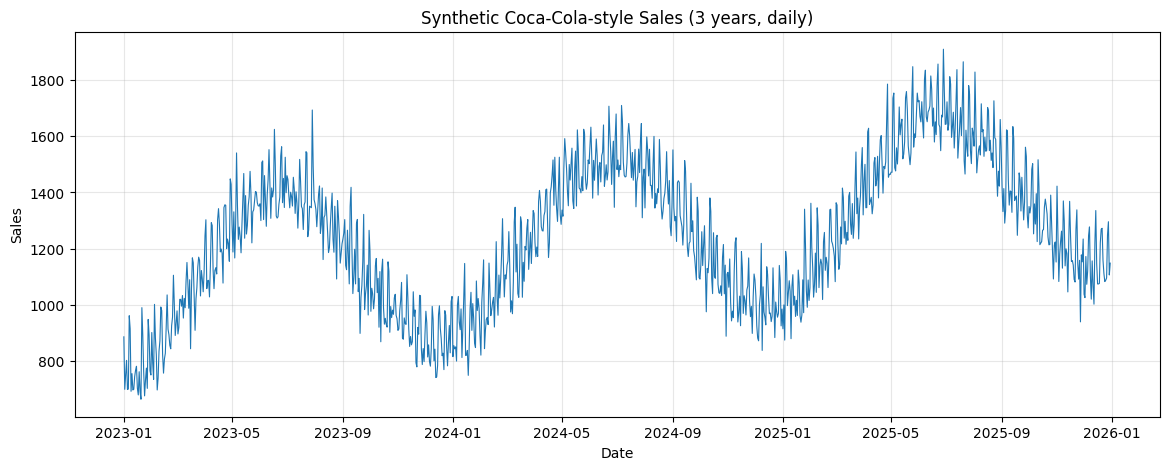

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(coke_df["date"], coke_df["sales"], linewidth=0.8)
plt.title("Synthetic Coca-Cola-style Sales (3 years, daily)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
coke_df_indexed = coke_df.set_index("date")
monthly_sales = coke_df_indexed["sales"].resample("M").mean()

print(monthly_sales.shape)
print(monthly_sales.head(12))

(36,)
date
2023-01-31     772.509786
2023-02-28     884.279127
2023-03-31    1042.917813
2023-04-30    1213.082863
2023-05-31    1326.573146
2023-06-30    1413.679248
2023-07-31    1393.756995
2023-08-31    1286.309607
2023-09-30    1154.098062
2023-10-31    1022.155067
2023-11-30     923.815065
2023-12-31     876.958289
Freq: ME, Name: sales, dtype: float64


/tmp/ipykernel_3074/2726451829.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = coke_df_indexed["sales"].resample("M").mean()


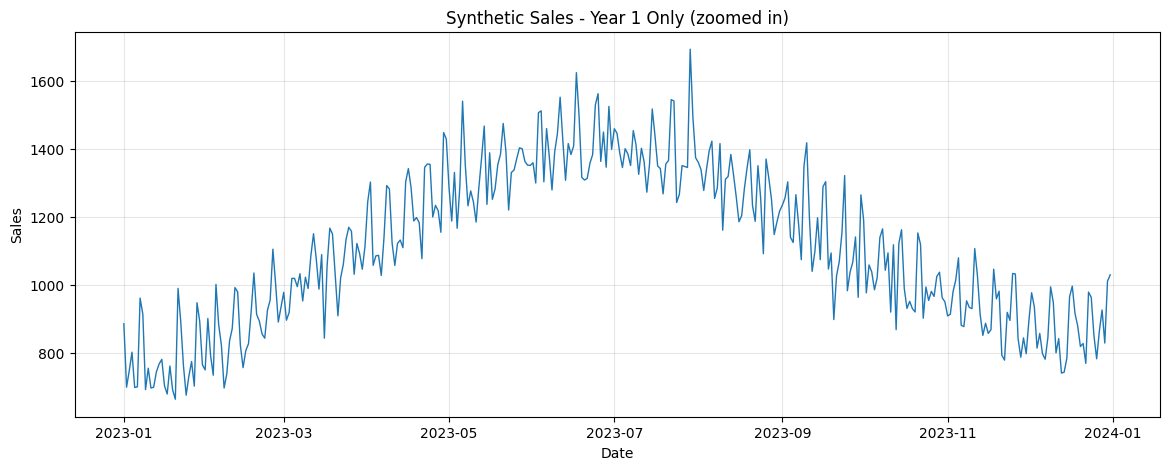

In [21]:
one_year = coke_df[coke_df["date"] < "2024-01-01"]

plt.figure(figsize=(14, 5))
plt.plot(one_year["date"], one_year["sales"], linewidth=1)
plt.title("Synthetic Sales - Year 1 Only (zoomed in)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
coke_df_indexed = coke_df.set_index("date")
monthly_sales = coke_df_indexed["sales"].resample("M").mean()

print(monthly_sales.shape)
print(monthly_sales.head(12))

(36,)
date
2023-01-31     772.509786
2023-02-28     884.279127
2023-03-31    1042.917813
2023-04-30    1213.082863
2023-05-31    1326.573146
2023-06-30    1413.679248
2023-07-31    1393.756995
2023-08-31    1286.309607
2023-09-30    1154.098062
2023-10-31    1022.155067
2023-11-30     923.815065
2023-12-31     876.958289
Freq: ME, Name: sales, dtype: float64


/tmp/ipykernel_3074/2726451829.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = coke_df_indexed["sales"].resample("M").mean()


In [23]:
monthly_values = monthly_sales.values.reshape(-1, 1)

scaler2 = MinMaxScaler(feature_range=(0, 1))
monthly_scaled = scaler2.fit_transform(monthly_values)

window_size = 3
X2, y2 = create_sequences(monthly_scaled, window_size)

train_size2 = int(len(X2) * 0.8)
X2_train, X2_test = X2[:train_size2], X2[train_size2:]
y2_train, y2_test = y2[:train_size2], y2[train_size2:]

X2_train = torch.FloatTensor(X2_train)
y2_train = torch.FloatTensor(y2_train)
X2_test = torch.FloatTensor(X2_test)
y2_test = torch.FloatTensor(y2_test)

print("Train examples:", len(X2_train))
print("Test examples:", len(X2_test))

Train examples: 26
Test examples: 7


In [24]:
model2 = SalesLSTM(input_size=1, hidden_size=32, num_layers=1).to(device)
criterion2 = nn.MSELoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

X2_train_dev = X2_train.to(device)
y2_train_dev = y2_train.to(device)

num_epochs = 200
for epoch in range(num_epochs):
    model2.train()
    optimizer2.zero_grad()
    outputs = model2(X2_train_dev)
    loss = criterion2(outputs, y2_train_dev)
    loss.backward()
    optimizer2.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {loss.item():.6f}")

Epoch [20/200]  Loss: 0.054800
Epoch [40/200]  Loss: 0.039255
Epoch [60/200]  Loss: 0.032701
Epoch [80/200]  Loss: 0.022183
Epoch [100/200]  Loss: 0.002282
Epoch [120/200]  Loss: 0.001914
Epoch [140/200]  Loss: 0.001755
Epoch [160/200]  Loss: 0.001682
Epoch [180/200]  Loss: 0.001632
Epoch [200/200]  Loss: 0.001581


In [25]:
model2.eval()
with torch.no_grad():
    X2_test_dev = X2_test.to(device)
    test_predictions2 = model2(X2_test_dev).cpu().numpy()

test_predictions2_real = scaler2.inverse_transform(test_predictions2)
y2_test_real = scaler2.inverse_transform(y2_test.numpy())

print("Predicted vs Actual:")
for pred, actual in zip(test_predictions2_real.flatten(), y2_test_real.flatten()):
    print(f"Predicted: {pred:.1f}   Actual: {actual:.1f}")

Predicted vs Actual:
Predicted: 1621.5   Actual: 1697.7
Predicted: 1622.8   Actual: 1645.9
Predicted: 1481.6   Actual: 1574.9
Predicted: 1343.1   Actual: 1412.5
Predicted: 1182.4   Actual: 1299.2
Predicted: 1086.1   Actual: 1192.5
Predicted: 1069.1   Actual: 1144.4


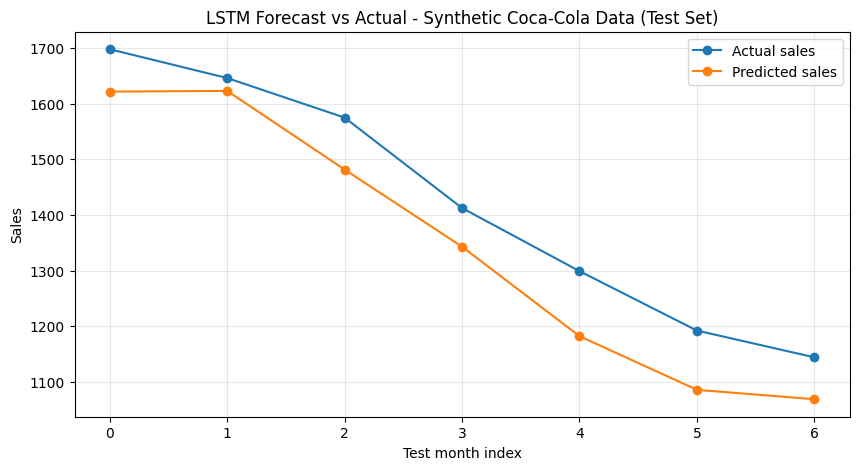

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(y2_test_real)), y2_test_real, marker="o", label="Actual sales")
plt.plot(range(len(test_predictions2_real)), test_predictions2_real, marker="o", label="Predicted sales")
plt.title("LSTM Forecast vs Actual - Synthetic Coca-Cola Data (Test Set)")
plt.xlabel("Test month index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
mae2 = mean_absolute_error(y2_test_real, test_predictions2_real)
mape2 = mean_absolute_percentage_error(y2_test_real, test_predictions2_real)

naive_predictions2 = y2_test_real[:-1]
naive_actual2 = y2_test_real[1:]
naive_mae2 = mean_absolute_error(naive_actual2, naive_predictions2)
naive_mape2 = mean_absolute_percentage_error(naive_actual2, naive_predictions2)

print(f"LSTM MAE: {mae2:.2f}   LSTM MAPE: {mape2*100:.2f}%")
print(f"Naive MAE: {naive_mae2:.2f}   Naive MAPE: {naive_mape2*100:.2f}%")

LSTM MAE: 80.06   LSTM MAPE: 5.89%
Naive MAE: 92.21   Naive MAPE: 6.84%
